1) Um determinado tipo de investimento rende 1,5% ao mês. Elabore um
programa em Python que recebe o valor inicial da aplicação em reais e o
número de meses aplicado, retornando o valor no final do período que é
a soma do valor inicial mais os juros. Apresente o valor aplicado mês a
mês em um gráfico de barras gerado pelo Python.

Valor final após 2 meses: R$ 123.63


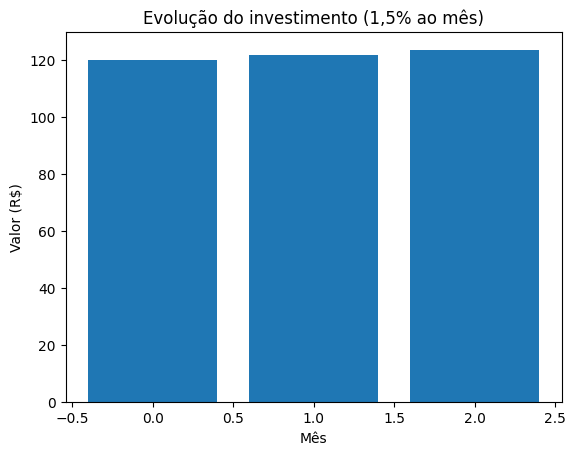

In [ ]:
import matplotlib.pyplot as plt

valor_inicial = float(input("Valor inicial (R$): "))
meses = int(input("Número de meses: "))

taxa = 1.5 / 100  # 1,5% ao mês

valores = [valor_inicial]
valor = valor_inicial

for m in range(1, meses + 1):
    valor = valor * (1 + taxa)
    valores.append(valor)

print(f"Valor final após {meses} meses: R$ {valor:.2f}")

# gráfico de barras
meses_eixo = list(range(0, meses + 1))  # 0 = valor inicial
plt.bar(meses_eixo, valores)
plt.xlabel("Mês")
plt.ylabel("Valor (R$)")
plt.title("Evolução do investimento (1,5% ao mês)")
plt.show()


Valor final após 2 meses: R$ 132.30


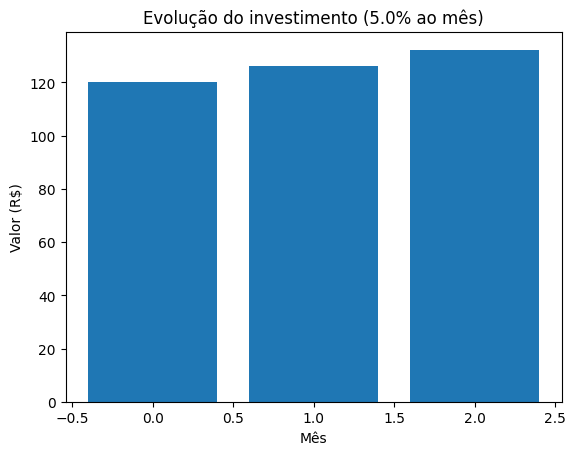

In [29]:
import matplotlib.pyplot as plt

valor_inicial = float(input("Valor inicial (R$): "))
meses = int(input("Número de meses: "))
taxa_mensal = float(input("Rentabilidade mensal (%): "))

taxa = taxa_mensal / 100

valores = [valor_inicial]
valor = valor_inicial

for m in range(1, meses + 1):
    valor = valor * (1 + taxa)
    valores.append(valor)

print(f"Valor final após {meses} meses: R$ {valor:.2f}")

meses_eixo = list(range(0, meses + 1))
plt.bar(meses_eixo, valores)
plt.xlabel("Mês")
plt.ylabel("Valor (R$)")
plt.title(f"Evolução do investimento ({taxa_mensal}% ao mês)")
plt.show()

Valor final após 1 meses: R$ 122.40
Mês 1: rendimento = 2.00%  valor acumulado = R$ 122.40


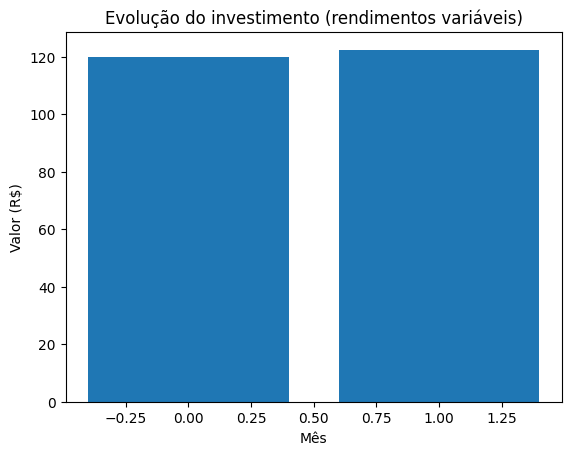

In [30]:
import matplotlib.pyplot as plt

valor_inicial = float(input("Valor inicial (R$): "))
texto = input("Digite os rendimentos mensais em %, separados por espaço: ")
rendimentos = [float(x) for x in texto.split()]

valor = valor_inicial
valores = [valor_inicial]

for r in rendimentos:
    taxa = r / 100
    valor = valor * (1 + taxa)
    valores.append(valor)

print(f"Valor final após {len(rendimentos)} meses: R$ {valor:.2f}")

for i, r in enumerate(rendimentos, start=1):
    print(f"Mês {i}: rendimento = {r:.2f}%  valor acumulado = R$ {valores[i]:.2f}")

meses_eixo = list(range(0, len(rendimentos) + 1))
plt.bar(meses_eixo, valores)
plt.xlabel("Mês")
plt.ylabel("Valor (R$)")
plt.title("Evolução do investimento (rendimentos variáveis)")
plt.show()


In [ ]:
import cv2
import numpy as np

img = cv2.imread("images.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Erro ao carregar a imagem. Confira o nome do arquivo (images.jpg).")
    exit()

linhas, colunas = img.shape

linhas_usable = linhas - (linhas % 2)
colunas_usable = colunas - (colunas % 2)

out = np.zeros((linhas_usable // 2, colunas_usable // 2), dtype=np.uint8)

for i in range(0, linhas_usable, 2):
    for j in range(0, colunas_usable, 2):
        bloco = img[i:i+2, j:j+2]
        media = int(np.mean(bloco))
        out[i // 2, j // 2] = media

cv2.imwrite("saida_2x2.png", out)

cv2.imshow("Original", img)
cv2.imshow("Reduzida 2x2", out)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
import cv2
import numpy as np

def reduzir_bloco(img, k):
    linhas, colunas = img.shape
    novas_linhas = linhas // k
    novas_colunas = colunas // k
    out = np.zeros((novas_linhas, novas_colunas), dtype=np.uint8)

    for i in range(0, novas_linhas):
        for j in range(0, novas_colunas):
            bloco = img[i*k:(i+1)*k, j*k:(j+1)*k]
            media = int(np.mean(bloco))
            out[i, j] = media
    return out

img = cv2.imread("entrada.png", cv2.IMREAD_GRAYSCALE)

for k in [3, 5, 6]:
    out = reduzir_bloco(img, k)
    cv2.imwrite(f"saida_{k}x{k}.png", out)


7) Modifique o programa 3 implementando um imposto que tributa o
rendimento no mês se o mesmo passar de 1,5%. O cálculo do imposto é
dado por:
imposto=(valor total aplicado do mês)*(rendimento no mês (%)-1,5)*0,001

Valor final após 1 meses: R$ 10799.35
Mês 1: rendimento = 8.00%  valor acumulado = R$ 10799.35


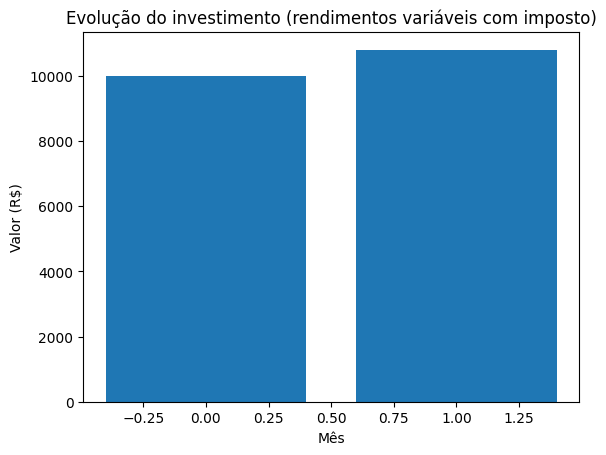

In [ ]:
import matplotlib.pyplot as plt

valor_inicial = float(input("Valor inicial (R$): "))
texto = input("Digite os rendimentos mensais em %, separados por espaço: ")
rendimentos = [float(x) for x in texto.split()]

valor = valor_inicial
valores = [valor_inicial]

for r in rendimentos:
    taxa = r / 100
    valor_total_aplicado = valor
    
    if r > 1.5:
        imposto = valor_total_aplicado * (r - 1.5) / 100 * 0.001
        rendimento_bruto = valor * taxa
        valor = valor + rendimento_bruto - imposto
    else:
        valor = valor * (1 + taxa)
    
    valores.append(valor)

print(f"Valor final após {len(rendimentos)} meses: R$ {valor:.2f}")

i = 1
for r in rendimentos:
    print(f"Mês {i}: rendimento = {r:.2f}%  valor acumulado = R$ {valores[i]:.2f}")
    i += 1

meses_eixo = list(range(0, len(rendimentos) + 1))
plt.bar(meses_eixo, valores)
plt.xlabel("Mês")
plt.ylabel("Valor (R$)")
plt.title("Evolução do investimento (rendimentos variáveis com imposto)")
plt.show()


4) Utilizando o programa de carregamento de imagem fornecido pelo
professor, implemente um programa em Python que tira a média de 4
pixels vizinhos e substitui este valor médio nos mesmo pixels que foram
utilizados para gerar a média. A figura abaixo ilustra o procedimento.

colunas

linhas

Você deve trabalhar com
imagens em tons de cinza e
este procedimento irá gerar
uma nova imagem com
resolução menor.

In [ ]:
import cv2
import numpy as np

# Carregamento básico da imagem (adaptado do padrão do professor)
def carregar_imagem(caminho):
    img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)  # Para tons de cinza
    return img

def salvar_imagem(img, nome_saida):
    cv2.imwrite(nome_saida, img)

def downsample_4pixels_cinza(img_original):
    altura_orig, largura_orig = img_original.shape
    # Nova resolução: metade da original
    nova_altura = altura_orig // 2
    nova_largura = largura_orig // 2
    
    img_nova = np.zeros((nova_altura, nova_largura), dtype=np.uint8)
    
    i = 0
    while i < nova_altura:
        j = 0
        while j < nova_largura:
            # 4 pixels vizinhos: (2i,2j), (2i,2j+1), (2i+1,2j), (2i+1,2j+1)
            soma = (img_original[2*i, 2*j] + 
                   img_original[2*i, 2*j+1] + 
                   img_original[2*i+1, 2*j] + 
                   img_original[2*i+1, 2*j+1])
            img_nova[i, j] = soma // 4  # Média aritmética
            j += 1
        i += 1
    
    return img_nova

# Exemplo de uso
img = carregar_imagem('entrada.jpg')
img_reduzida = downsample_4pixels_cinza(img)
salvar_imagem(img_reduzida, 'saida_4pixels.jpg')





5) Modifique o programa anterior implementando grupos de 9, 25 e 36
pixels e verifique o resultado.

6) Modifique os programas 4 e 5 utilizando imagens coloridas. Você
deverá calcular 3 médias, uma para o verde, uma para o vermelho e
uma para o azul.